# **Translator v1.4 Training Notebook — Combined Gender Context**<br>

## **1.** Data Upload

In [3]:
import sys, pickle
import pandas as pd
sys.path.append('../modules')
from modules.BPE_tokenizer import tokenize_eng, tokenize_pol, build_tokenizers, build_encoders, make_ref_encoder
from modules import Data, Model_ref, Trainer, Predict
from tqdm.auto import tqdm
tqdm.pandas()

In [4]:
with open("../local_data/translator_v2/data_final_opensub.pkl", 'rb') as f:
    df_data = pickle.load(f)

df_data['self_ref'].value_counts()

self_ref
NA_OTHER    2344012
NA           680342
M            163730
F             69396
Name: count, dtype: int64

In [5]:
df_data['addr_ref'].value_counts()

addr_ref
NA_OTHER    2390813
NA           572055
M            164454
F             65243
P             64915
Name: count, dtype: int64

## **2.** Rebalancing The Neutral Pools (NA -> F / M)

In [6]:
NA_DONATION = 40000

df_data = Data.sample_ref_conversion(df_data, 'self_ref', 'M', NA_DONATION, na_val='NA', random_state=42)
df_data = Data.sample_ref_conversion(df_data, 'self_ref', 'F', NA_DONATION, na_val='NA', random_state=42)

In [7]:
df_data = Data.sample_ref_conversion(df_data, 'addr_ref', 'M', NA_DONATION, na_val='NA', random_state=42)
df_data = Data.sample_ref_conversion(df_data, 'addr_ref', 'F', NA_DONATION, na_val='NA', random_state=42)

## **3.** Tokenization

In [8]:
df_data['eng_split'] = df_data['eng_text'].apply(tokenize_eng)
df_data['pol_split'] = df_data['pol_text'].apply(tokenize_pol)

## **4.** Training BPE Tokenizers

In [9]:
tokenizer_eng, tokenizer_pol = build_tokenizers(df_data, 'eng_split', 'pol_split',
                                                 eng_vocab_size=36000, pol_vocab_size=54000, num_switch=600,
                                                 ref_tokens=['<addr_na>', '<addr_m>', '<addr_f>', '<addr_p>',
                                                             '<self_na>', '<self_m>', '<self_f>'])

Src vocab size: 115933 | Tgt vocab size: 334197


In [10]:
tokenizer_eng.train_bpe()

  0%|          | 0/35944 [00:00<?, ?it/s]

In [11]:
tokenizer_pol.train_bpe()

  0%|          | 0/53926 [00:00<?, ?it/s]

## **5.** Building Encoders & Encoding IDs

In [ ]:
encoder_eng, encoder_pol = build_encoders(tokenizer_eng, tokenizer_pol, thres_eng=56, thres_pol=74)

In [19]:
encode_pol_row = make_ref_encoder(tokenizer_pol, encoder_pol,
                                   [('self_ref', {'F': '<self_f>', 'M': '<self_m>', 'NA': '<self_na>', 'NA_OTHER': '<self_na>'}),
                                    ('addr_ref', {'F': '<addr_f>', 'M': '<addr_m>', 'P': '<addr_p>', 'NA': '<addr_na>', 'NA_OTHER': '<addr_na>'})])

df_data['eng_ids'] = df_data['eng_split'].progress_apply(lambda tab: encoder_eng.encode_snt(tab) + [tokenizer_eng.vocab['<eos>']])
df_data['pol_ids'] = df_data.progress_apply(encode_pol_row, axis=1)

  0%|          | 0/3257480 [00:00<?, ?it/s]

  0%|          | 0/3257480 [00:00<?, ?it/s]

## **6.** Trimming By Length & Sampling

In [20]:
df_data = Data.trim_by_ids(df_data, ['eng_ids', 'pol_ids'], max_len=26)

Dropped 5825 / 3257480 rows exceeding max_len=26


In [21]:
df_data = df_data.sample(1500000, random_state=42).reset_index(drop=True)

## **7.** Train/Val Split

In [22]:
df_train, df_val = Data.shuffle_split(df_data, 0.90)
print(f"{df_train.shape}, {df_val.shape}")

train_data = Data.EngPolDataset(df_train, 'eng_ids', 'pol_ids')
val_data = Data.EngPolDataset(df_val, 'eng_ids', 'pol_ids')

(1350000, 8), (150000, 8)


## **8.** Hyperparameters & Model

In [25]:
num_hiddens, num_blks, dropout = 512, 4, 0.3
ffn_num_hiddens, num_heads = 1024, 8
max_seq = 27

encoder = Model_ref.TransformerEncoder(36000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout, max_seq)
decoder = Model_ref.TransformerDecoder(54000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout, max_seq)
model = Model_ref.Seq2Seq(encoder=encoder, decoder=decoder, lr=0.0001, pad_id=0, n_ref=2, device='cuda')

trainer = Trainer.TrainerModule(batch_size=64)
trainer.plotter_init("V1.4, Combined Gender Context Model")

## **9.** Training

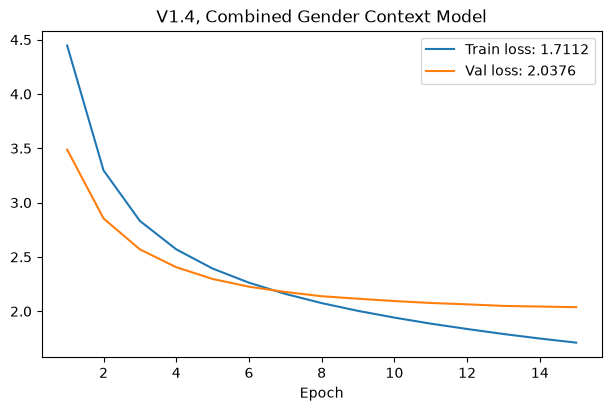

In [26]:
trainer.fit(model, train_data, val_data, 15, '../checkpoints/translator_v1_4-')

## **10.** Saving Tokenizers & Encoders

In [27]:
Data.save_artifacts('../local_data/model_reference/translator_v1_4',
                     tokenizer_eng=tokenizer_eng, tokenizer_pol=tokenizer_pol,
                     encoder_eng=encoder_eng, encoder_pol=encoder_pol)

## **11.** Sanity Check

In [28]:
predicter = Predict.PredictionModule(tokenizer_eng, tokenizer_pol, encoder_eng, encoder_pol, model)
predicter.translate_snt("I have never been to Paris.", ['self_f', 'addr_na'])

'Nigdy nie byłam w paryżu.'